In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE

In [4]:
df = pd.read_csv("../results/clustering_results.csv")

df.head()

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,file_name,GMM_cluster,DBSCAN_cluster
0,-1.063756,0.165255,0.691232,0.246091,0.834620,0.754703,0.890069,0.424851,0.780238,0.928137,...,0.032998,0.030189,0.017152,0.025025,0.041286,0.090386,0.122804,03-01-01-01-01-01-01.wav,1,0
1,-0.994626,0.277280,0.510977,0.358848,1.173437,0.858311,0.704162,0.687790,0.734243,0.446494,...,0.032998,0.030190,0.017150,0.025026,0.041285,0.090387,0.122805,03-01-01-01-01-02-01.wav,1,0
2,-0.954325,0.242716,0.744771,0.211534,0.967347,0.384805,0.907501,0.695574,0.545731,0.673504,...,-1.830874,-1.792491,-1.642013,-1.670757,-1.592613,-1.465834,-1.391754,03-01-01-01-02-01-01.wav,1,-1
3,-0.915118,0.099359,0.902350,0.372147,0.933726,0.609970,1.105841,0.915741,0.450237,0.488136,...,-1.556583,-1.845502,-2.018470,-2.301329,-2.252764,-1.681633,-1.013032,03-01-01-01-02-02-01.wav,0,-1
4,-1.392440,0.653942,0.922824,0.535235,0.972075,0.888982,0.886653,0.716942,0.400051,1.125225,...,-2.827963,-2.797626,-2.522053,-2.391194,-2.025809,-1.575707,-1.233482,03-01-02-01-01-01-01.wav,0,-1


In [5]:
features = df.drop(columns=["file_name","GMM_cluster","DBSCAN_cluster"])


In [6]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate=200
)

tsne_results = tsne.fit_transform(features)

In [7]:
df["TSNE_1"] = tsne_results[:,0]
df["TSNE_2"] = tsne_results[:,1]

df.head()

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,file_name,GMM_cluster,DBSCAN_cluster,TSNE_1,TSNE_2
0,-1.063756,0.165255,0.691232,0.246091,0.834620,0.754703,0.890069,0.424851,0.780238,0.928137,...,0.017152,0.025025,0.041286,0.090386,0.122804,03-01-01-01-01-01-01.wav,1,0,23.706699,-5.235367
1,-0.994626,0.277280,0.510977,0.358848,1.173437,0.858311,0.704162,0.687790,0.734243,0.446494,...,0.017150,0.025026,0.041285,0.090387,0.122805,03-01-01-01-01-02-01.wav,1,0,23.905962,-4.756847
2,-0.954325,0.242716,0.744771,0.211534,0.967347,0.384805,0.907501,0.695574,0.545731,0.673504,...,-1.642013,-1.670757,-1.592613,-1.465834,-1.391754,03-01-01-01-02-01-01.wav,1,-1,46.885693,4.034204
3,-0.915118,0.099359,0.902350,0.372147,0.933726,0.609970,1.105841,0.915741,0.450237,0.488136,...,-2.018470,-2.301329,-2.252764,-1.681633,-1.013032,03-01-01-01-02-02-01.wav,0,-1,47.205959,4.293386
4,-1.392440,0.653942,0.922824,0.535235,0.972075,0.888982,0.886653,0.716942,0.400051,1.125225,...,-2.522053,-2.391194,-2.025809,-1.575707,-1.233482,03-01-02-01-01-01-01.wav,0,-1,50.136734,8.375077


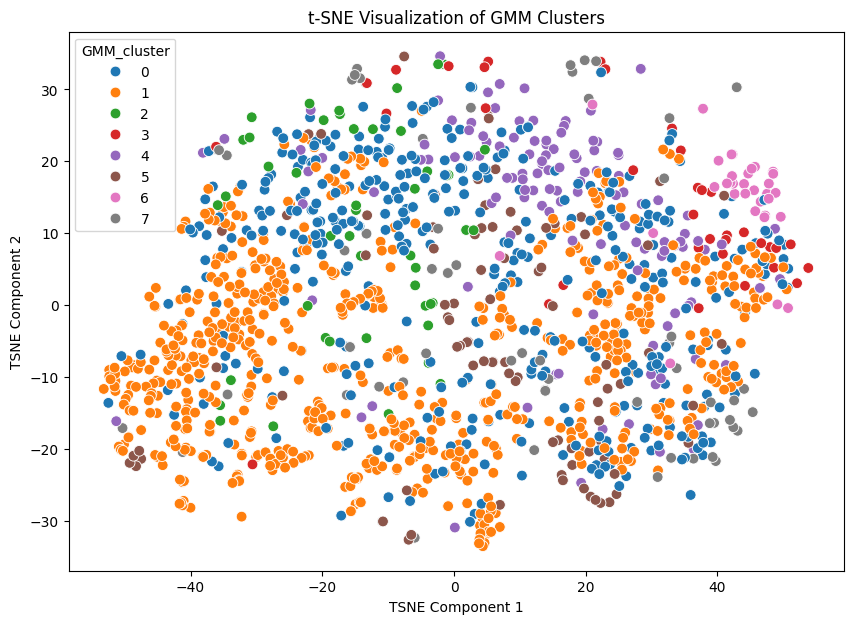

In [8]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df["TSNE_1"],
    y=df["TSNE_2"],
    hue=df["GMM_cluster"],
    palette="tab10",
    s=60
)

plt.title("t-SNE Visualization of GMM Clusters")
plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.savefig("../results/tsne_gmm_clusters.png", dpi=300)

plt.show()

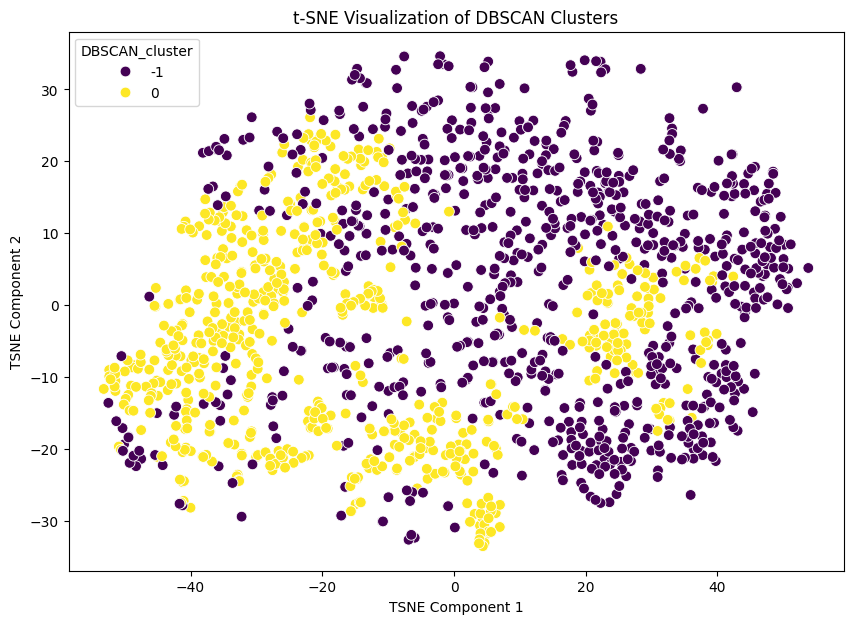

In [9]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=df["TSNE_1"],
    y=df["TSNE_2"],
    hue=df["DBSCAN_cluster"],
    palette="viridis",
    s=60
)

plt.title("t-SNE Visualization of DBSCAN Clusters")
plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.savefig("../results/tsne_dbscan_clusters.png", dpi=300)

plt.show()

In [10]:
df.to_csv("../data/processed/audio_features_with_clusters_tsne.csv", index=False)

## t-SNE Visualization

To visualize high-dimensional audio features, we applied **t-SNE (t-distributed Stochastic Neighbor Embedding)**.

t-SNE is a dimensionality reduction technique that converts high-dimensional data into a lower dimensional space while preserving the local structure of the data.

In this project:

• Original feature space: **39 dimensions**  
• Reduced feature space: **2 dimensions**

This allows us to visualize cluster structures produced by the clustering algorithms.

Two visualizations were generated:

1. **GMM Cluster Visualization**  
2. **DBSCAN Cluster Visualization**

These plots help in understanding how the audio samples are grouped in the feature space and whether distinct clusters emerge.

### t-SNE Visualization

t-SNE was used to reduce the 39-dimensional MFCC feature space into a 2-dimensional representation for visualization.

The GMM clustering plot shows multiple overlapping clusters, indicating that emotional speech samples share similar acoustic patterns.

The DBSCAN visualization reveals a single dense cluster along with several noise points. This behavior is expected because density-based clustering methods often struggle with high-dimensional audio features.

Overall, the visualizations demonstrate that speech emotions are not perfectly separable using MFCC features alone, but clustering algorithms can still identify underlying structure in the acoustic data.